In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import *
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from numpy import argmax
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from yellowbrick.classifier import ROCAUC, ClassificationReport, PrecisionRecallCurve
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import *
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

In [18]:
from sklearn.datasets import fetch_20newsgroups
news = fetch_20newsgroups(subset='all', categories=['comp.graphics', 'rec.sport.baseball', 'sci.space'])

In [19]:
vectorizer = CountVectorizer(max_features=5000)
X = vectorizer.fit_transform(news.data)
y = news.target

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM (rbf)': SVC(kernel='rbf'),
    'SVM (poly)': SVC(kernel='poly', degree=3),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
}

In [25]:
results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    start = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start
    
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc, train_time, predict_time])

In [26]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Train Time', 'Predict Time'])
print(results_df.sort_values('Accuracy', ascending=False))

                 Model  Accuracy  Train Time  Predict Time
4                  MLP  0.978003    1.370497      0.001175
0  Logistic Regression  0.964467    0.150559      0.000171
1            SVM (rbf)  0.888325    2.060535      0.426723
3                  KNN  0.774958    0.000423      0.055742
2           SVM (poly)  0.424704    2.857284      0.535531


In [28]:
best_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

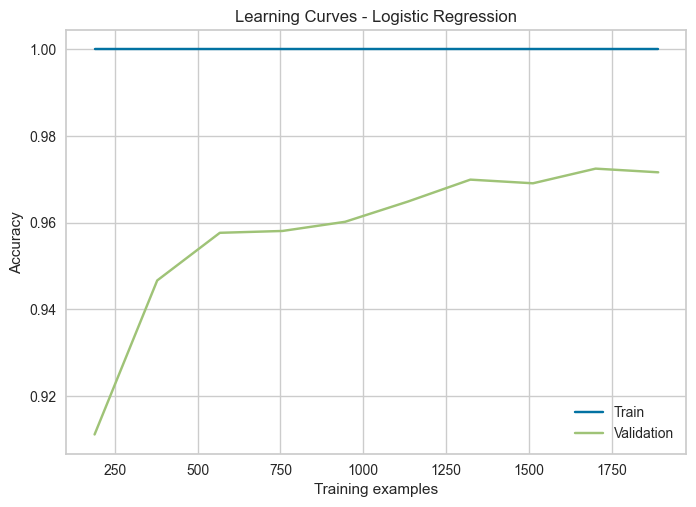

In [31]:
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curves - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()